In [2]:
import sys

print("Python version:", sys.version)
print("Python executable:", sys.executable)

Python version: 3.11.15 | packaged by Anaconda, Inc. | (main, Jun 11 2026, 15:12:53) [MSC v.1942 64 bit (AMD64)]
Python executable: c:\Users\Rohit\anaconda3\envs\cvd-ml\python.exe


In [3]:
import numpy as np
import joblib

# Load preprocessed CVD data
X_train_scaled = np.load("../artifacts/cvd/X_train_scaled.npy")
X_test_scaled = np.load("../artifacts/cvd/X_test_scaled.npy")

y_train = np.load("../artifacts/cvd/y_train.npy")
y_test = np.load("../artifacts/cvd/y_test.npy")

# Load the fitted scaler
scaler = joblib.load("../artifacts/cvd/scaler.pkl")

print("CVD data loaded successfully!")

CVD data loaded successfully!


In [4]:
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape :", X_test_scaled.shape)
print("y_train shape       :", y_train.shape)
print("y_test shape        :", y_test.shape)

print("\nMissing values:")
print("X_train:", np.isnan(X_train_scaled).sum())
print("X_test :", np.isnan(X_test_scaled).sum())
print("y_train:", np.isnan(y_train).sum())
print("y_test :", np.isnan(y_test).sum())

X_train_scaled shape: (54958, 11)
X_test_scaled shape : (13740, 11)
y_train shape       : (54958,)
y_test shape        : (13740,)

Missing values:
X_train: 0
X_test : 0
y_train: 0
y_test : 0


In [5]:
unique, counts = np.unique(y_train, return_counts=True)

print("Training target distribution:")

for label, count in zip(unique, counts):
    percentage = (count / len(y_train)) * 100
    print(f"Class {label}: {count} ({percentage:.2f}%)")

Training target distribution:
Class 0: 27765 (50.52%)
Class 1: 27193 (49.48%)


In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version: ", tf.__version__)


TensorFlow version:  2.21.0


In [7]:
# Define ANN input layer and first hidden layer

model = keras.Sequential([
    layers.Input(shape=(11,)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.30),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.20),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

print("Input layer and first hidden layer created successfully!")

Input layer and first hidden layer created successfully!


In [8]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,393 (13.25 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
#Keras needs to know how the model should learn. so we need to compile the model with an optimizer, loss function, and metrics.
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [10]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7148 - loss: 0.5727 - val_accuracy: 0.7285 - val_loss: 0.5502
Epoch 2/100
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7259 - loss: 0.5576 - val_accuracy: 0.7332 - val_loss: 0.5500
Epoch 3/100
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7285 - loss: 0.5548 - val_accuracy: 0.7307 - val_loss: 0.5467
Epoch 4/100
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7302 - loss: 0.5531 - val_accuracy: 0.7328 - val_loss: 0.5455
Epoch 5/100
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7299 - loss: 0.5514 - val_accuracy: 0.7324 - val_loss: 0.5465
Epoch 6/100
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7306 - loss: 0.5496 - val_accuracy: 0.7334 - val_loss: 0.5436
Epoch 7/100
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7309 - loss: 0.5494 - val_accuracy: 0.7338 - val_loss: 0.5440
Epoch 8/100
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 1s 999us/step - accuracy: 0.7300 - loss:

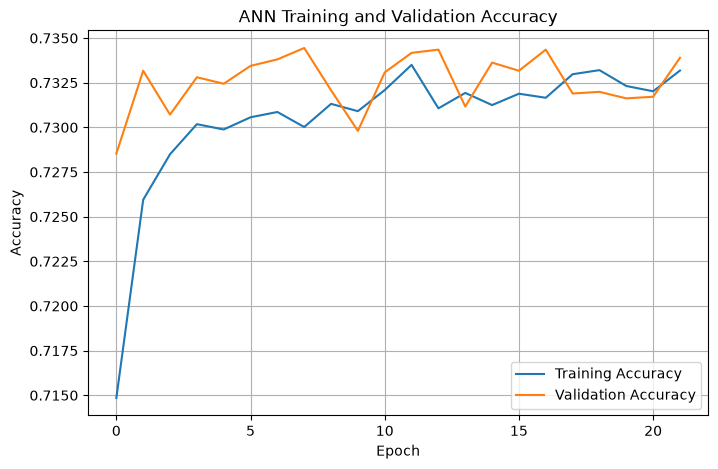

In [11]:
#Step 17 — Plot Training History
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN Training and Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

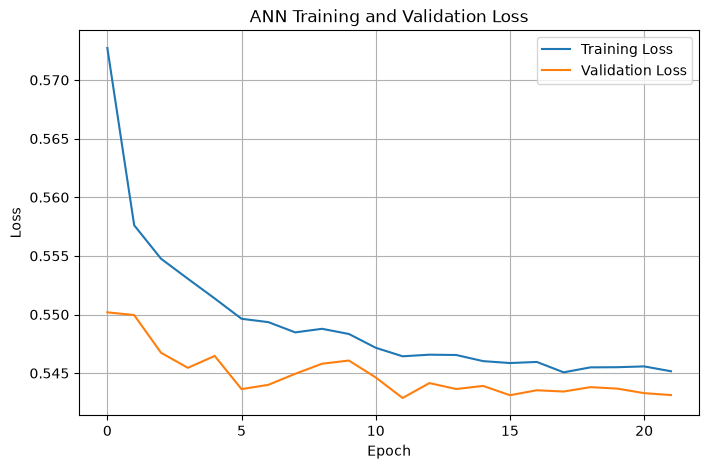

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ANN Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [13]:
test_loss, test_accuracy = model.evaluate(
    X_test_scaled,
    y_test,
    verbose=1
)

print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7339 - loss: 0.5366

Test Loss: 0.536616325378418
Test Accuracy: 0.7339155673980713


In [14]:
y_pred_prob = model.predict(X_test_scaled)

print("Prediction shape:", y_pred_prob.shape)
print("\nFirst 10 predicted probabilities:")
print(y_pred_prob[:10].ravel())

430/430 ━━━━━━━━━━━━━━━━━━━━ 0s 487us/step
Prediction shape: (13740, 1)

First 10 predicted probabilities:
[0.13382463 0.4405096  0.8549714  0.8409864  0.59916514 0.31595948
 0.5495528  0.28925562 0.31049034 0.5100074 ]


In [15]:
y_pred = (y_pred_prob >= 0.5).astype(int).ravel()

print("Prediction shape:", y_pred.shape)

print("\nFirst 10 predicted classes:")
print(y_pred[:10])

print("\nPredicted class distribution:")
unique, counts = np.unique(y_pred, return_counts=True)

for label, count in zip(unique, counts):
    percentage = (count / len(y_pred)) * 100
    print(f"Class {label}: {count} ({percentage:.2f}%)")

Prediction shape: (13740,)

First 10 predicted classes:
[0 0 1 1 1 0 1 0 0 1]

Predicted class distribution:
Class 0: 6745 (49.09%)
Class 1: 6995 (50.91%)


Confusion Matrix:
[[5015 1926]
 [1730 5069]]


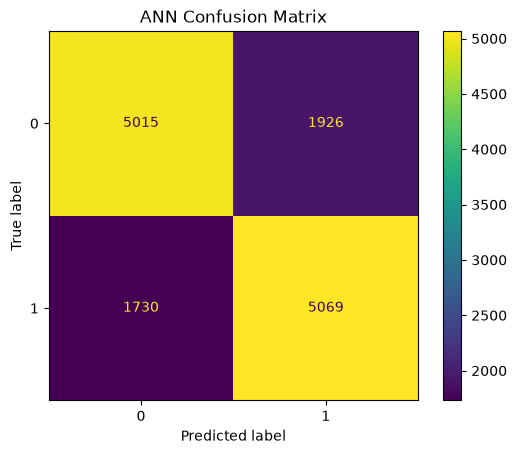

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0, 1]
)

disp.plot()
plt.title("ANN Confusion Matrix")
plt.show()

In [17]:
# Convert predicted probabilities to 1D array
y_pred_prob = model.predict(X_test_scaled).ravel()

# Convert probabilities into class predictions
y_pred = (y_pred_prob >= 0.5).astype(int)

430/430 ━━━━━━━━━━━━━━━━━━━━ 0s 517us/step


In [18]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

specificity = tn / (tn + fp)

roc_auc = roc_auc_score(y_test, y_pred_prob)

print("Evaluation Metrics")
print("------------------")
print(f"Accuracy    : {accuracy:.4f}")
print(f"Precision   : {precision:.4f}")
print(f"Recall      : {recall:.4f}")
print(f"Specificity : {specificity:.4f}")
print(f"F1-Score    : {f1:.4f}")
print(f"ROC-AUC     : {roc_auc:.4f}")

Evaluation Metrics
------------------
Accuracy    : 0.7339
Precision   : 0.7247
Recall      : 0.7456
Specificity : 0.7225
F1-Score    : 0.7350
ROC-AUC     : 0.8066


In [19]:
from sklearn.metrics import classification_report

print("Classification Report")
print("---------------------")
print(classification_report(y_test, y_pred))

Classification Report
---------------------
              precision    recall  f1-score   support

           0       0.74      0.72      0.73      6941
           1       0.72      0.75      0.73      6799

    accuracy                           0.73     13740
   macro avg       0.73      0.73      0.73     13740
weighted avg       0.73      0.73      0.73     13740



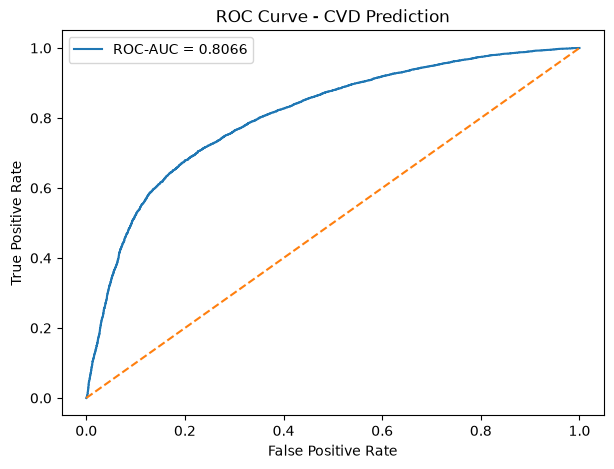

In [20]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - CVD Prediction")
plt.legend()
plt.show()

In [21]:
# Step 3 — Model Comparison
# Step 3A — Logistic Regression

from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

logistic_pred_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]
logistic_pred = (logistic_pred_prob >= 0.5).astype(int)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [22]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

accuracy = accuracy_score(y_test, logistic_pred)
precision = precision_score(y_test, logistic_pred)
recall = recall_score(y_test, logistic_pred)
f1 = f1_score(y_test, logistic_pred)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    logistic_pred
).ravel()

specificity = tn / (tn + fp)

roc_auc = roc_auc_score(
    y_test,
    logistic_pred_prob
)

print("Logistic Regression Evaluation")
print("--------------------------------")
print(f"Accuracy    : {accuracy:.4f}")
print(f"Precision   : {precision:.4f}")
print(f"Recall      : {recall:.4f}")
print(f"Specificity : {specificity:.4f}")
print(f"F1-Score    : {f1:.4f}")
print(f"ROC-AUC     : {roc_auc:.4f}")

Logistic Regression Evaluation
--------------------------------
Accuracy    : 0.7307
Precision   : 0.7545
Recall      : 0.6757
Specificity : 0.7846
F1-Score    : 0.7129
ROC-AUC     : 0.7952


In [23]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

decision_tree_model.fit(X_train_scaled, y_train)

decision_tree_pred_prob = decision_tree_model.predict_proba(X_test_scaled)[:, 1]
decision_tree_pred = (decision_tree_pred_prob >= 0.5).astype(int)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [24]:
accuracy = accuracy_score(y_test, decision_tree_pred)
precision = precision_score(y_test, decision_tree_pred)
recall = recall_score(y_test, decision_tree_pred)
f1 = f1_score(y_test, decision_tree_pred)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    decision_tree_pred
).ravel()

specificity = tn / (tn + fp)

roc_auc = roc_auc_score(
    y_test,
    decision_tree_pred_prob
)

print("Decision Tree Evaluation")
print("------------------------")
print(f"Accuracy    : {accuracy:.4f}")
print(f"Precision   : {precision:.4f}")
print(f"Recall      : {recall:.4f}")
print(f"Specificity : {specificity:.4f}")
print(f"F1-Score    : {f1:.4f}")
print(f"ROC-AUC     : {roc_auc:.4f}")

Decision Tree Evaluation
------------------------
Accuracy    : 0.7362
Precision   : 0.7559
Recall      : 0.6895
Specificity : 0.7819
F1-Score    : 0.7212
ROC-AUC     : 0.7964


In [25]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train_scaled, y_train)

random_forest_pred_prob = random_forest_model.predict_proba(
    X_test_scaled
)[:, 1]

random_forest_pred = (
    random_forest_pred_prob >= 0.5
).astype(int)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [26]:
accuracy = accuracy_score(y_test, random_forest_pred)
precision = precision_score(y_test, random_forest_pred)
recall = recall_score(y_test, random_forest_pred)
f1 = f1_score(y_test, random_forest_pred)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    random_forest_pred
).ravel()

specificity = tn / (tn + fp)

roc_auc = roc_auc_score(
    y_test,
    random_forest_pred_prob
)

print("Random Forest Evaluation")
print("------------------------")
print(f"Accuracy    : {accuracy:.4f}")
print(f"Precision   : {precision:.4f}")
print(f"Recall      : {recall:.4f}")
print(f"Specificity : {specificity:.4f}")
print(f"F1-Score    : {f1:.4f}")
print(f"ROC-AUC     : {roc_auc:.4f}")

Random Forest Evaluation
------------------------
Accuracy    : 0.7144
Precision   : 0.7109
Recall      : 0.7126
Specificity : 0.7162
F1-Score    : 0.7118
ROC-AUC     : 0.7718


In [27]:
from sklearn.ensemble import GradientBoostingClassifier

gradient_boosting_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gradient_boosting_model.fit(X_train_scaled, y_train)

gradient_boosting_pred_prob = gradient_boosting_model.predict_proba(
    X_test_scaled
)[:, 1]

gradient_boosting_pred = (
    gradient_boosting_pred_prob >= 0.5
).astype(int)

print("Gradient Boosting trained successfully!")

Gradient Boosting trained successfully!


In [28]:
accuracy = accuracy_score(y_test, gradient_boosting_pred)
precision = precision_score(y_test, gradient_boosting_pred)
recall = recall_score(y_test, gradient_boosting_pred)
f1 = f1_score(y_test, gradient_boosting_pred)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    gradient_boosting_pred
).ravel()

specificity = tn / (tn + fp)

roc_auc = roc_auc_score(
    y_test,
    gradient_boosting_pred_prob
)

print("Gradient Boosting Evaluation")
print("----------------------------")
print(f"Accuracy    : {accuracy:.4f}")
print(f"Precision   : {precision:.4f}")
print(f"Recall      : {recall:.4f}")
print(f"Specificity : {specificity:.4f}")
print(f"F1-Score    : {f1:.4f}")
print(f"ROC-AUC     : {roc_auc:.4f}")

Gradient Boosting Evaluation
----------------------------
Accuracy    : 0.7379
Precision   : 0.7535
Recall      : 0.6991
Specificity : 0.7760
F1-Score    : 0.7253
ROC-AUC     : 0.8076


In [29]:
import pandas as pd

comparison_results = pd.DataFrame({
    "Model": [
        "ANN",
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        0.7339,
        0.7307,
        0.7362,
        0.7144,
        0.7379
    ],
    "Precision": [
        0.7247,
        0.7545,
        0.7559,
        0.7109,
        0.7535
    ],
    "Recall": [
        0.7456,
        0.6757,
        0.6895,
        0.7126,
        0.6991
    ],
    "Specificity": [
        0.7225,
        0.7846,
        0.7819,
        0.7162,
        0.7760
    ],
    "F1-Score": [
        0.7350,
        0.7129,
        0.7212,
        0.7118,
        0.7253
    ],
    "ROC-AUC": [
        0.8066,
        0.7952,
        0.7964,
        0.7718,
        0.8076
    ]
})

comparison_results

,Model,Accuracy,Precision,Recall,Specificity,F1-Score,ROC-AUC
0,ANN,0.7339,0.7247,0.7456,0.7225,0.7350,0.8066
1,Logistic Regression,0.7307,0.7545,0.6757,0.7846,0.7129,0.7952
2,Decision Tree,0.7362,0.7559,0.6895,0.7819,0.7212,0.7964
3,Random Forest,0.7144,0.7109,0.7126,0.7162,0.7118,0.7718
4,Gradient Boosting,0.7379,0.7535,0.6991,0.7760,0.7253,0.8076


In [30]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

In [31]:
param_grid = {
    "n_estimators": [100, 150, 200],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

In [32]:
gradient_boosting_base = GradientBoostingClassifier(
    random_state=42
)

grid_search = GridSearchCV(
    estimator=gradient_boosting_base,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation ROC-AUC:")
print(f"{grid_search.best_score_:.4f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters:
{'learning_rate': 0.05, 'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 150}

Best cross-validation ROC-AUC:
0.7998


In [33]:
# Get the best tuned Gradient Boosting model
best_gb_model = grid_search.best_estimator_

# Predict probabilities on the test set
tuned_gb_pred_prob = best_gb_model.predict_proba(X_test_scaled)[:, 1]

# Convert probabilities to class predictions
tuned_gb_pred = (tuned_gb_pred_prob >= 0.5).astype(int)

print("Prediction shape:", tuned_gb_pred.shape)
print("First 10 predicted classes:", tuned_gb_pred[:10])

Prediction shape: (13740,)
First 10 predicted classes: [0 0 1 1 1 0 1 0 0 1]


In [34]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

accuracy = accuracy_score(y_test, tuned_gb_pred)
precision = precision_score(y_test, tuned_gb_pred)
recall = recall_score(y_test, tuned_gb_pred)

tn, fp, fn, tp = confusion_matrix(y_test, tuned_gb_pred).ravel()

specificity = tn / (tn + fp)
f1 = f1_score(y_test, tuned_gb_pred)
roc_auc = roc_auc_score(y_test, tuned_gb_pred_prob)

print("Tuned Gradient Boosting Results")
print("--------------------------------")
print(f"Accuracy    : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision   : {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall      : {recall:.4f} ({recall*100:.2f}%)")
print(f"Specificity : {specificity:.4f} ({specificity*100:.2f}%)")
print(f"F1 Score    : {f1:.4f} ({f1*100:.2f}%)")
print(f"ROC-AUC     : {roc_auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, tuned_gb_pred))

Tuned Gradient Boosting Results
--------------------------------
Accuracy    : 0.7388 (73.88%)
Precision   : 0.7555 (75.55%)
Recall      : 0.6980 (69.80%)
Specificity : 0.7787 (77.87%)
F1 Score    : 0.7256 (72.56%)
ROC-AUC     : 0.8078

Confusion Matrix:
[[5405 1536]
 [2053 4746]]


In [35]:
# Save tuned Gradient Boosting results

tuned_gb_results = {
    "Model": "Tuned Gradient Boosting",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "Specificity": specificity,
    "F1": f1,
    "ROC-AUC": roc_auc
}

print(tuned_gb_results)

{'Model': 'Tuned Gradient Boosting', 'Accuracy': 0.7387918486171762, 'Precision': 0.7554918815663801, 'Recall': 0.6980438299749964, 'Specificity': np.float64(0.7787062382941939), 'F1': 0.7256325968962618, 'ROC-AUC': 0.8077532927872157}


In [36]:
import joblib

joblib.dump(best_gb_model, "../artifacts/cvd/tuned_gradient_boosting.pkl")

print("Tuned Gradient Boosting model saved successfully.")

Tuned Gradient Boosting model saved successfully.


In [37]:
import os

print(os.path.exists("../artifacts/cvd/tuned_gradient_boosting.pkl"))

True
